# Question 1: Intensity Transformations on the Runway Image

Apply the following intensity transforms to the runway image:
- **(a)** Gamma correction with γ = 0.5
- **(b)** Gamma correction with γ = 2
- **(c)** Contrast Stretching (piecewise linear), r₁ = 0.2, r₂ = 0.8

In [3]:
%matplotlib inline
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


## Load the Runway Image
> Place the runway image at `images/runway.png`

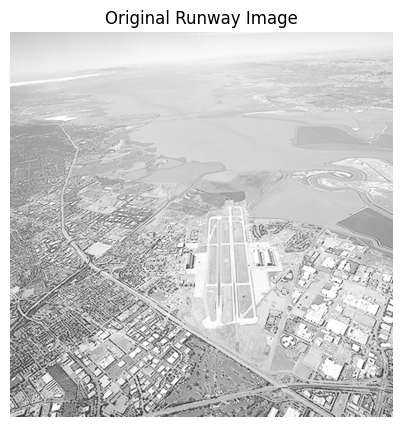

Image shape: (769, 765)


In [4]:
f = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, "Could not load runway image. Check the images/ folder."

plt.figure(figsize=(6, 5))
plt.imshow(f, cmap='gray', vmin=0, vmax=255)
plt.title('Original Runway Image')
plt.axis('off')
plt.show()
print('Image shape:', f.shape)

## (a) Gamma Correction — γ = 0.5

The transform is: $s = r^{\gamma}$ where intensities are normalised to $[0, 1]$.

With **γ < 1**, the curve bows upward — dark pixels are brightened more than bright ones.

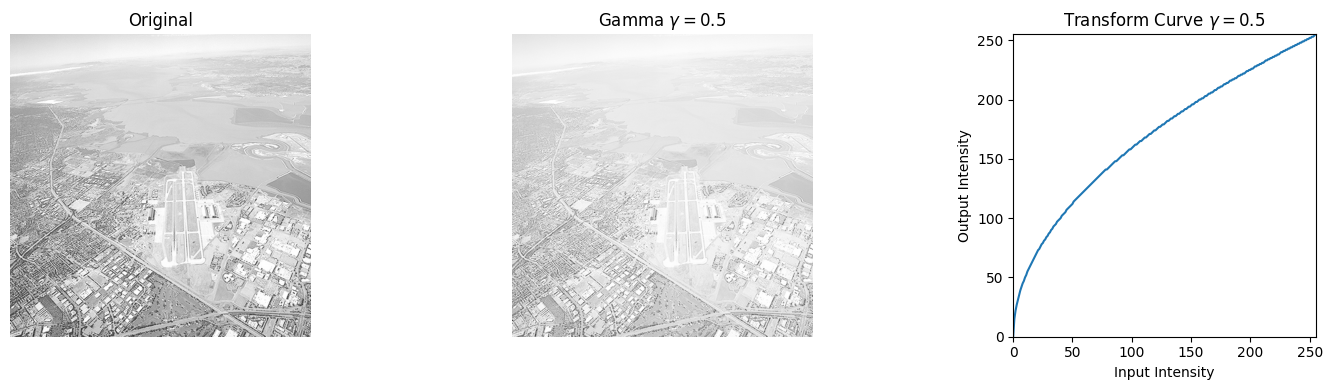

In [5]:
gamma_a = 0.5
lut_a = np.array([(i / 255.0) ** gamma_a * 255 for i in range(256)], dtype=np.uint8)
g_a = cv.LUT(f, lut_a)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(g_a, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(r'Gamma $\gamma=0.5$')
axes[1].axis('off')

axes[2].plot(lut_a)
axes[2].set_title(r'Transform Curve $\gamma=0.5$')
axes[2].set_xlabel('Input Intensity')
axes[2].set_ylabel('Output Intensity')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('output/q1a_gamma_0.5.png', dpi=150, bbox_inches='tight')
plt.show()

## (b) Gamma Correction — γ = 2

With **γ > 1**, the curve bows downward — bright pixels are compressed, overall image darkens.

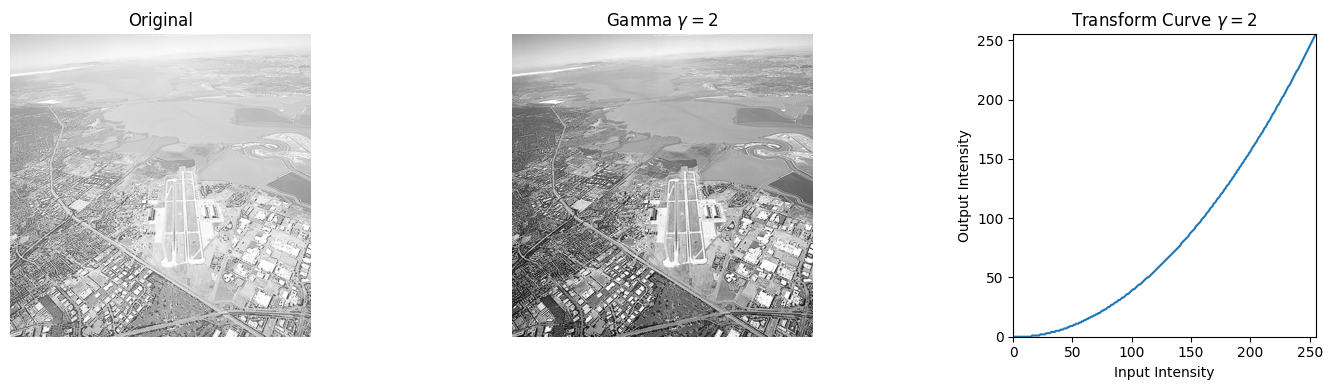

In [6]:
gamma_b = 2.0
lut_b = np.array([(i / 255.0) ** gamma_b * 255 for i in range(256)], dtype=np.uint8)
g_b = cv.LUT(f, lut_b)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(g_b, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(r'Gamma $\gamma=2$')
axes[1].axis('off')

axes[2].plot(lut_b)
axes[2].set_title(r'Transform Curve $\gamma=2$')
axes[2].set_xlabel('Input Intensity')
axes[2].set_ylabel('Output Intensity')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('output/q1b_gamma_2.png', dpi=150, bbox_inches='tight')
plt.show()

## (c) Contrast Stretching (Piecewise Linear)

$$
s(r) = \begin{cases}
0 & r < r_1 \\
\dfrac{r - r_1}{r_2 - r_1} & r_1 \le r \le r_2 \\
1 & r > r_2
\end{cases}
$$

where $r_1 = 0.2$, $r_2 = 0.8$. Pixels below $r_1$ are clipped to black, above $r_2$ to white, and the mid-range is linearly stretched to full contrast.

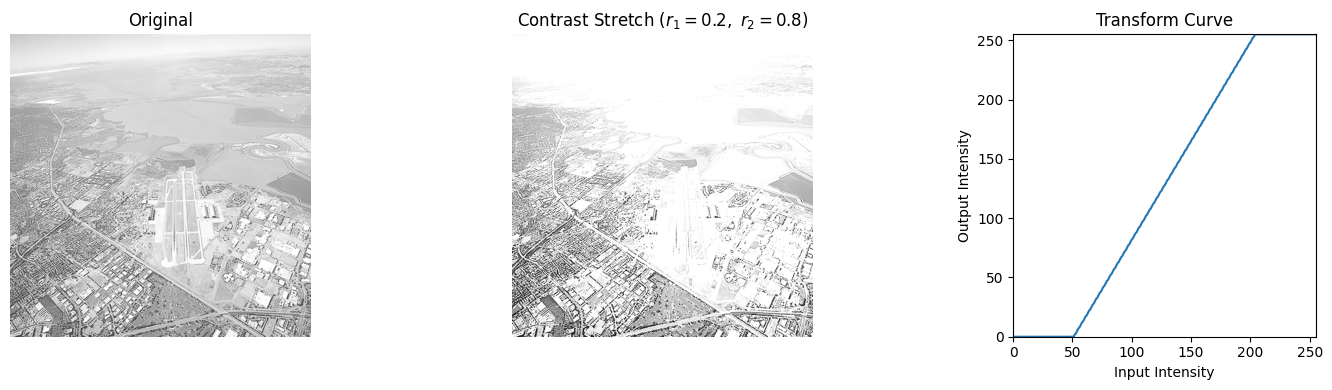

In [7]:
r1, r2 = 0.2, 0.8

def contrast_stretch_lut(r1, r2):
    """Build a 256-entry LUT for the piecewise contrast stretching function."""
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        r = i / 255.0          # normalise to [0, 1]
        if r < r1:
            s = 0.0
        elif r <= r2:
            s = (r - r1) / (r2 - r1)
        else:
            s = 1.0
        lut[i] = np.clip(round(s * 255), 0, 255)
    return lut

lut_c = contrast_stretch_lut(r1, r2)
g_c = cv.LUT(f, lut_c)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(g_c, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(r'Contrast Stretch ($r_1=0.2,\ r_2=0.8$)')
axes[1].axis('off')

axes[2].plot(lut_c)
axes[2].set_title('Transform Curve')
axes[2].set_xlabel('Input Intensity')
axes[2].set_ylabel('Output Intensity')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('output/q1c_contrast_stretch.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — All Transforms Side by Side

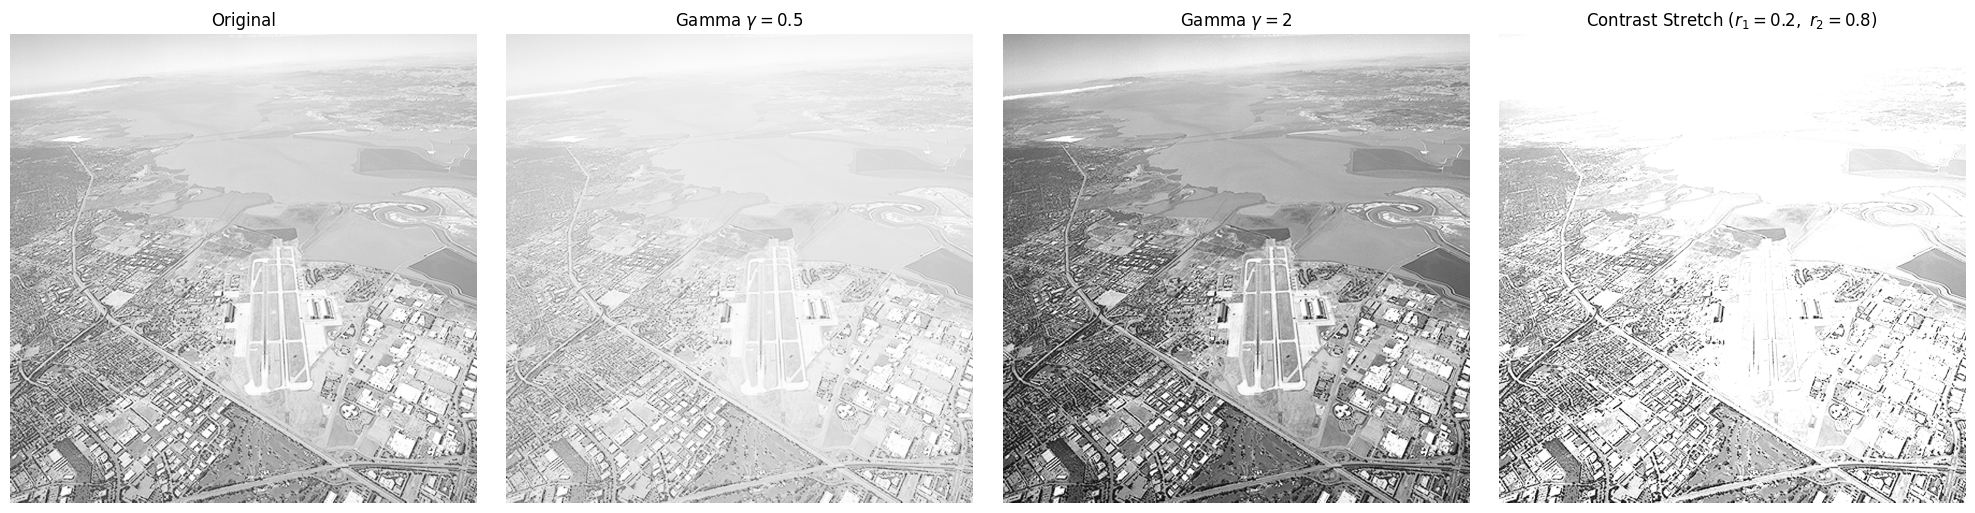

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
images = [f, g_a, g_b, g_c]
titles = [
    'Original',
    r'Gamma $\gamma=0.5$',
    r'Gamma $\gamma=2$',
    r'Contrast Stretch ($r_1=0.2,\ r_2=0.8$)',
]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('output/q1_summary.png', dpi=150, bbox_inches='tight')
plt.show()